In [2]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import squarify

In [ ]:
pasta = r"C:\Users\Wanderson\Documents\Estacio\AulasVSCode\EcommerceOlist\olist"

In [4]:
print("Pasta existe?", os.path.exists(pasta))

📂 Pasta existe? True


In [6]:
arquivos = {
    "categories": "product_category_name_translation.csv",
    "customers": "olist_customers_dataset.csv",
    "sellers": "olist_sellers_dataset.csv",
    "order_items": "olist_order_items_dataset.csv",
    "products": "olist_products_dataset.csv",
    "orders": "olist_orders_dataset.csv",
    "payments": "olist_order_payments_dataset.csv",
    "geolocation": "olist_geolocation_dataset.csv",
    "reviews": "olist_order_reviews_dataset.csv"
}

dfs = {nome: pd.read_csv(os.path.join(pasta, arquivo)) for nome, arquivo in arquivos.items()}

for nome, df in dfs.items():
    print(f"{nome:12s} -> {df.shape[0]:>7,d} linhas x {df.shape[1]:>2d} colunas")

categories   ->      71 linhas x  2 colunas
customers    ->  99,441 linhas x  5 colunas
sellers      ->   3,095 linhas x  4 colunas
order_items  -> 112,650 linhas x  7 colunas
products     ->  32,951 linhas x  9 colunas
orders       ->  99,441 linhas x  8 colunas
payments     -> 103,886 linhas x  5 colunas
geolocation  -> 1,000,162 linhas x  5 colunas
reviews      ->  99,223 linhas x  7 colunas


In [7]:
dfs["orders"].head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [8]:
df = (
    dfs["orders"]
    .merge(dfs["order_items"], on="order_id", how="left")
    .merge(dfs["products"], on="product_id", how="left")
    .merge(dfs["customers"], on="customer_id", how="left")
)

print(df.shape)
df.head()

(113425, 26)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,...,268.0,4.0,500.0,19.0,8.0,13.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,595fac2a385ac33a80bd5114aec74eb8,...,178.0,1.0,400.0,19.0,13.0,19.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,aa4383b373c6aca5d8797843e5594415,...,232.0,1.0,420.0,24.0,19.0,21.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,...,468.0,3.0,450.0,30.0,10.0,20.0,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1.0,65266b2da20d04dbe00c5c2d3bb7859e,...,316.0,4.0,250.0,51.0,15.0,15.0,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [9]:
dfs = {
    "categories": pd.read_csv(os.path.join(pasta, "product_category_name_translation.csv")),
    "sellers": pd.read_csv(os.path.join(pasta, "olist_sellers_dataset.csv")),
    "order_items": pd.read_csv(os.path.join(pasta, "olist_order_items_dataset.csv")),
    "products": pd.read_csv(os.path.join(pasta, "olist_products_dataset.csv")),
    "geolocation": pd.read_csv(os.path.join(pasta, "olist_geolocation_dataset.csv")),
}

In [10]:
produtos_cat = dfs["products"].merge(
    dfs["categories"], on="product_category_name", how="left"
)

itens_prod = dfs["order_items"].merge(
    produtos_cat, on="product_id", how="left"
)

vendedores = dfs["sellers"].merge(
    itens_prod, on="seller_id", how="left"
)

geo = dfs["geolocation"].drop_duplicates(subset="geolocation_zip_code_prefix")
vendedores_geo = vendedores.merge(
    geo,
    left_on="seller_zip_code_prefix",
    right_on="geolocation_zip_code_prefix",
    how="left"
)

In [11]:
vendedores_geo.info()
vendedores_geo.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 24 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   seller_id                      112650 non-null  object 
 1   seller_zip_code_prefix         112650 non-null  int64  
 2   seller_city                    112650 non-null  object 
 3   seller_state                   112650 non-null  object 
 4   order_id                       112650 non-null  object 
 5   order_item_id                  112650 non-null  int64  
 6   product_id                     112650 non-null  object 
 7   shipping_limit_date            112650 non-null  object 
 8   price                          112650 non-null  float64
 9   freight_value                  112650 non-null  float64
 10  product_category_name          111047 non-null  object 
 11  product_name_lenght            111047 non-null  float64
 12  product_description_lenght    

,seller_id,seller_zip_code_prefix,seller_city,seller_state,order_id,order_item_id,product_id,shipping_limit_date,price,freight_value,...,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP,4a90af3e85dd563884e2afeab1091394,1,ffb64e34a37740dafb6c88f1abd1fa61,2017-08-25 20:50:19,106.20,9.56,...,700.0,43.0,15.0,35.0,sports_leisure,13023.0,-22.898536,-47.063125,campinas,SP
1,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP,6d953888a914b67350d5bc4d48f2acab,1,f4621f8ad6f54a2e3c408884068be46d,2017-05-11 16:25:11,101.70,15.92,...,600.0,35.0,15.0,28.0,sports_leisure,13023.0,-22.898536,-47.063125,campinas,SP
2,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP,bc8a5de6abf5b14f98a6135a7fb46731,2,325a06bcce0da45b7f4ecf2797dd40e4,2017-09-05 12:50:19,10.80,2.42,...,300.0,16.0,5.0,15.0,sports_leisure,13023.0,-22.898536,-47.063125,campinas,SP
3,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP,035201c3c82a97f8a25dd6bd5244b2d5,1,1c36a5285f7f3b1ed2637d7c528ce5ff,2017-11-22 04:30:29,89.99,45.09,...,1600.0,55.0,37.0,30.0,luggage_accessories,13844.0,-22.382941,-46.946641,mogi-guacu,SP
4,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP,0504447548229e075dea8441b37b1e2a,1,8852eb03b04ec3268a66e9b696e25f6f,2017-10-06 02:14:42,199.90,21.89,...,2000.0,25.0,55.0,40.0,stationery,13844.0,-22.382941,-46.946641,mogi-guacu,SP


In [12]:
vendedores_geo.columns

Index(['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state',
       'order_id', 'order_item_id', 'product_id', 'shipping_limit_date',
       'price', 'freight_value', 'product_category_name',
       'product_name_lenght', 'product_description_lenght',
       'product_photos_qty', 'product_weight_g', 'product_length_cm',
       'product_height_cm', 'product_width_cm',
       'product_category_name_english', 'geolocation_zip_code_prefix',
       'geolocation_lat', 'geolocation_lng', 'geolocation_city',
       'geolocation_state'],
      dtype='object')

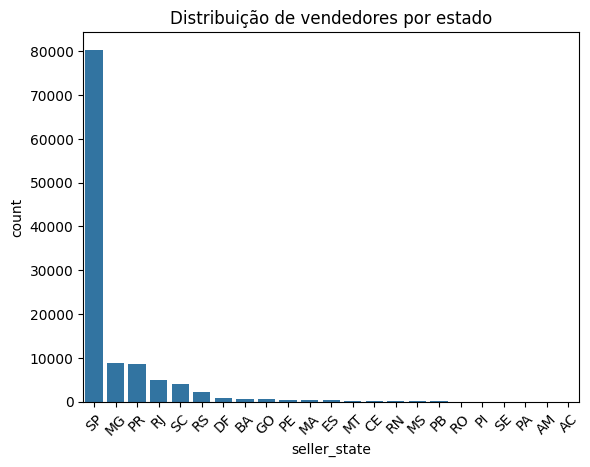

In [13]:
sns.countplot(data=vendedores_geo, x="seller_state", order=vendedores_geo["seller_state"].value_counts().index)
plt.title("Distribuição de vendedores por estado")
plt.xticks(rotation=45)
plt.show()

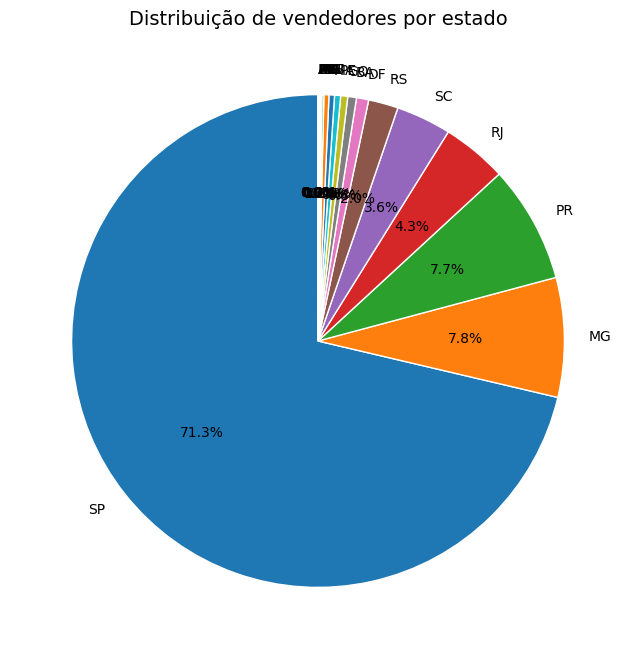

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
vendedores_geo['seller_state'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white'}
)

plt.title("Distribuição de vendedores por estado", fontsize=14)
plt.ylabel('')
plt.show()

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# =====  Ajuste opcional para permitir emojis no Windows  =====
plt.rcParams['font.family'] = 'Segoe UI Emoji'
# =============================================================

# Cria a série com o número de vendedores por estado
vendedores_estado = vendedores_geo['seller_state'].value_counts()

# Define a paleta de cores
cores = sns.color_palette("pastel", len(vendedores_estado))

# Cria a figura com dois gráficos lado a lado
fig, ax = plt.subplots(1, 2, figsize=(14, 7))

# ---- Gráfico de Pizza ----
ax[0].pie(
    vendedores_estado,
    labels=vendedores_estado.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=cores,
    wedgeprops={'edgecolor': 'white'}
)
ax[0].set_title("Distribuição por Estado", fontsize=14, fontweight='bold')

# ---- Gráfico de Barras ---- (versão sem warning)
sns.barplot(
    y=vendedores_estado.index,
    x=vendedores_estado.values,
    hue=vendedores_estado.index,   # evita o FutureWarning
    legend=False,                  # evita legenda duplicada
    palette="pastel",
    ax=ax[1]
)

ax[1].set_title("Número de Vendedores", fontsize=14, fontweight='bold')
ax[1].set_xlabel("Quantidade")
ax[1].set_ylabel("Estado")

plt.tight_layout()
plt.show()



NameError: name 'vendedores_geo' is not defined

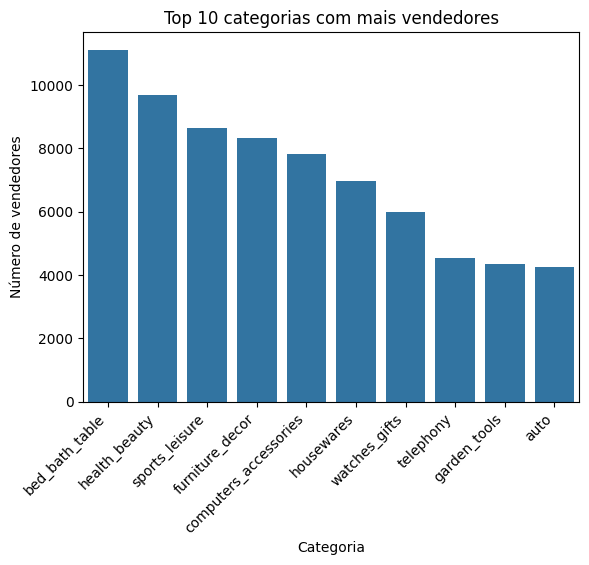

In [16]:
top_categorias = (
    vendedores_geo["product_category_name_english"]
    .value_counts()
    .head(10)
    .reset_index()
)

sns.barplot(data=top_categorias, x="product_category_name_english", y="count")
plt.title("Top 10 categorias com mais vendedores")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Número de vendedores")
plt.xlabel("Categoria")
plt.show()


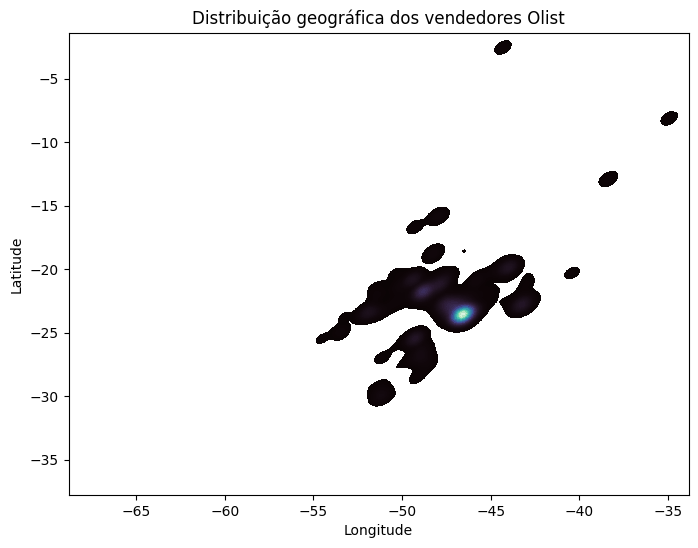

In [17]:
plt.figure(figsize=(8, 6))
sns.kdeplot(
    data=vendedores_geo,
    x="geolocation_lng",
    y="geolocation_lat",
    fill=True,
    cmap="mako",
    levels=50,
    thresh=0.05
)
plt.title("Distribuição geográfica dos vendedores Olist")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


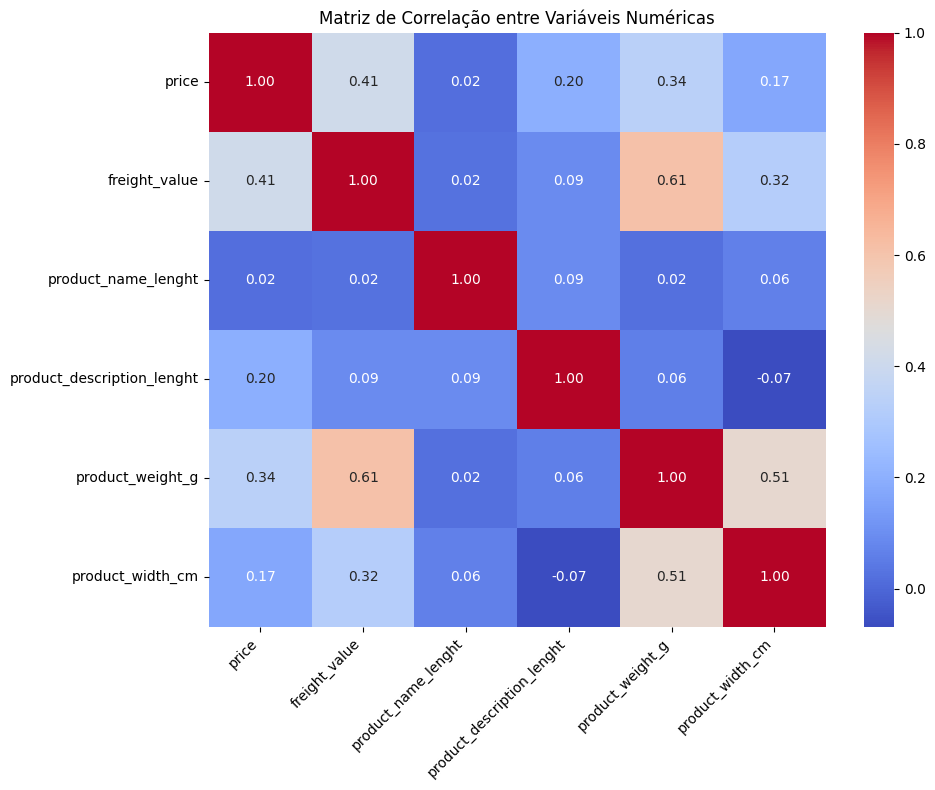

In [18]:
from matplotlib import color_sequences

# Definindo as colunas numéricas para o mapa de calor
cols = [
    'price',
    'freight_value',
    'product_name_lenght',
    'product_description_lenght',
    'product_weight_g',
    'product_width_cm'
]

# Filtrar apenas as colunas presentes no DataFrame 'df'
# e que não são totalmente nulas para calcular a correlação
valid_cols = [col for col in cols if col in df.columns and df[col].notna().any()]

# Verificar se há colunas válidas para calcular a correlação
if valid_cols:
    plt.figure(figsize=(10, 8)) # Ajuste o tamanho da figura para melhor visualização
    sns.heatmap(df[valid_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Matriz de Correlação entre Variáveis Numéricas")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout() # Ajusta o layout para evitar sobreposição
    plt.show()
else:
    print("Nenhuma coluna numérica válida encontrada para calcular a correlação.")

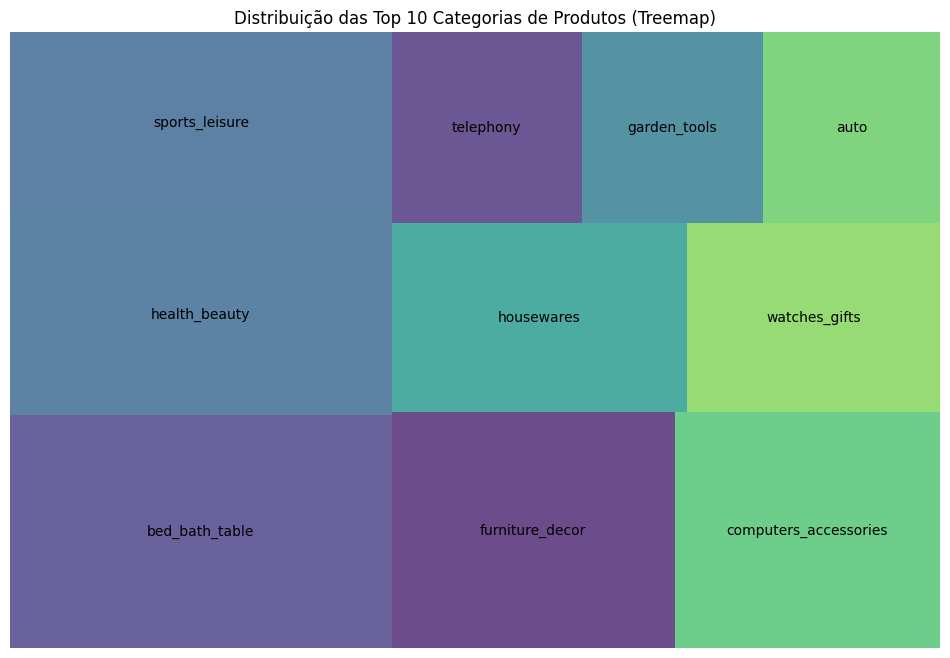

In [19]:
# Contar a frequência de cada categoria de produto
category_counts = vendedores_geo['product_category_name_english'].value_counts().head(10)

# Preparar os dados para squarify
sizes = category_counts.values
labels = category_counts.index

# Criar o treemap
plt.figure(figsize=(12, 8))
squarify.plot(sizes=sizes, label=labels, alpha=.8)
plt.title('Distribuição das Top 10 Categorias de Produtos (Treemap)')
plt.axis('off') # Remove os eixos
plt.show()